In [ ]:
%pip install tables

In [1]:
import tables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
print("Imports ready.")


Imports ready.


In [2]:
H5_PATH = "../data/raw/ukdale.h5"

h5 = tables.open_file(H5_PATH, mode="r")
table = h5.get_node("/building1/elec/meter1/table")

print("Meter1 table:", table)
print("Columns:", table.colnames)
print("Total rows:", table.nrows)


Meter1 table: /building1/elec/meter1/table (Table(np.int64(21837636),)shuffle, blosc(9)) ''
Columns: ['index', 'values_block_0']
Total rows: 21837636


In [3]:
colnames = table.colnames
print("Available columns:", colnames)

power_field = None
for candidate in ["power", "power_active", "power_apparent", "values_block_0"]:
    if candidate in colnames:
        power_field = candidate
        break

if power_field is None:
    raise ValueError("No recognizable power column found.")

print("Using power field:", power_field)


Available columns: ['index', 'values_block_0']
Using power field: values_block_0


In [4]:
def stream_mains_hourly(table, power_field, chunk_size=200_000):
    """
    Stream NILMTK PyTables meter table in chunks,
    convert nanosecond timestamps, aggregate to hourly,
    and return a combined hourly DataFrame.
    """
    nrows = table.nrows
    hourly_chunks = []

    for start in range(0, nrows, chunk_size):
        stop = min(start + chunk_size, nrows)
        print(f"Processing rows {start} to {stop} ...")

        # Read timestamps (NILMTK stores them in nanoseconds)
        ts_raw = table.read(start, stop, field="index")

        # Read power values
        if power_field == "values_block_0":
            vals_raw = table.read(start, stop, field=power_field)[:, 0]
        else:
            vals_raw = table.read(start, stop, field=power_field)

        # Convert timestamps correctly (ns → datetime)
        df_chunk = pd.DataFrame({
            "timestamp": pd.to_datetime(ts_raw, unit="ns", utc=True),
            "power_watts": vals_raw.astype("float32")
        })

        df_chunk = df_chunk.set_index("timestamp").sort_index()

        # Hourly aggregation for this chunk (lowercase 'h')
        df_hourly_chunk = df_chunk.resample("1h").mean()

        hourly_chunks.append(df_hourly_chunk)

    # Combine all hourly chunks
    df_hourly = pd.concat(hourly_chunks)
    df_hourly = df_hourly.groupby(df_hourly.index).mean().sort_index()

    return df_hourly


In [5]:
df_hourly = stream_mains_hourly(table, power_field, chunk_size=200_000)

print("Hourly dataframe shape:", df_hourly.shape)
df_hourly.head()


Processing rows 0 to 200000 ...
Processing rows 200000 to 400000 ...
Processing rows 400000 to 600000 ...
Processing rows 600000 to 800000 ...
Processing rows 800000 to 1000000 ...
Processing rows 1000000 to 1200000 ...
Processing rows 1200000 to 1400000 ...
Processing rows 1400000 to 1600000 ...
Processing rows 1600000 to 1800000 ...
Processing rows 1800000 to 2000000 ...
Processing rows 2000000 to 2200000 ...
Processing rows 2200000 to 2400000 ...
Processing rows 2400000 to 2600000 ...
Processing rows 2600000 to 2800000 ...
Processing rows 2800000 to 3000000 ...
Processing rows 3000000 to 3200000 ...
Processing rows 3200000 to 3400000 ...
Processing rows 3400000 to 3600000 ...
Processing rows 3600000 to 3800000 ...
Processing rows 3800000 to 4000000 ...
Processing rows 4000000 to 4200000 ...
Processing rows 4200000 to 4400000 ...
Processing rows 4400000 to 4600000 ...
Processing rows 4600000 to 4800000 ...
Processing rows 4800000 to 5000000 ...
Processing rows 5000000 to 5200000 ...


,power_watts
timestamp,
2012-11-09 22:00:00+00:00,474.804413
2012-11-09 23:00:00+00:00,442.738037
2012-11-10 00:00:00+00:00,608.406860
2012-11-10 01:00:00+00:00,826.403381
2012-11-10 02:00:00+00:00,173.122131


In [6]:
df_hourly = df_hourly.dropna()
df_hourly = df_hourly[df_hourly["power_watts"] >= 0]

print("After cleaning:", df_hourly.shape)
df_hourly.head()


After cleaning: (37843, 1)


,power_watts
timestamp,
2012-11-09 22:00:00+00:00,474.804413
2012-11-09 23:00:00+00:00,442.738037
2012-11-10 00:00:00+00:00,608.406860
2012-11-10 01:00:00+00:00,826.403381
2012-11-10 02:00:00+00:00,173.122131


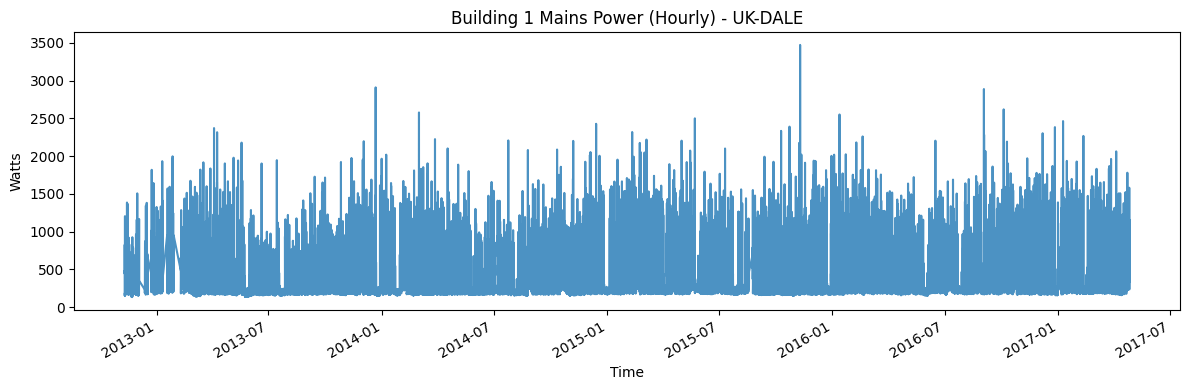

In [7]:
plt.figure(figsize=(12, 4))
df_hourly["power_watts"].plot(alpha=0.8)
plt.title("Building 1 Mains Power (Hourly) - UK-DALE")
plt.ylabel("Watts")
plt.xlabel("Time")
plt.tight_layout()
plt.show()


In [8]:
OUT_PATH = "../data/interim/House_1_cleaned.csv"
df_hourly.to_csv(OUT_PATH)
print("Saved hourly mains to:", OUT_PATH)


Saved hourly mains to: ../data/interim/House_1_cleaned.csv
